Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading sentiment analysis files...
VADER file loaded: (1717, 14)
VADER columns: ['Hotel name', 'Reviewer Name', 'Rating', 'Traveller Type', 'Date of Review', 'Liked', 'Disliked', 'Review Summary', 'Stay Duration', 'Stay Date', 'Unnamed: 10', 'review_length', 'sentiment_score', 'sentiment']
BERT file loaded: (1717, 14)
BERT columns: ['Hotel name', 'Reviewer Name', 'Rating', 'Traveller Type', 'Date of Review', 'Liked', 'Disliked', 'Review Summary', 'Stay Duration', 'Stay Date', 'Unnamed: 10', 'stars', 'sentiment_score', 'sentiment']
RoBERTa file loaded: (1717, 16)
RoBERTa columns: ['Hotel name', 'Reviewer Name', 'Rating', 'Traveller Type', 'Date of Review', 'Liked', 'Disliked', 'Review Summary', 'Stay Duration', 'Stay Date', 'Unnamed: 10', 'review_length', 'sentiment_label', 'sentiment_score', 'sentiment_class', 'sentiment_binary']

Standardizing column names.

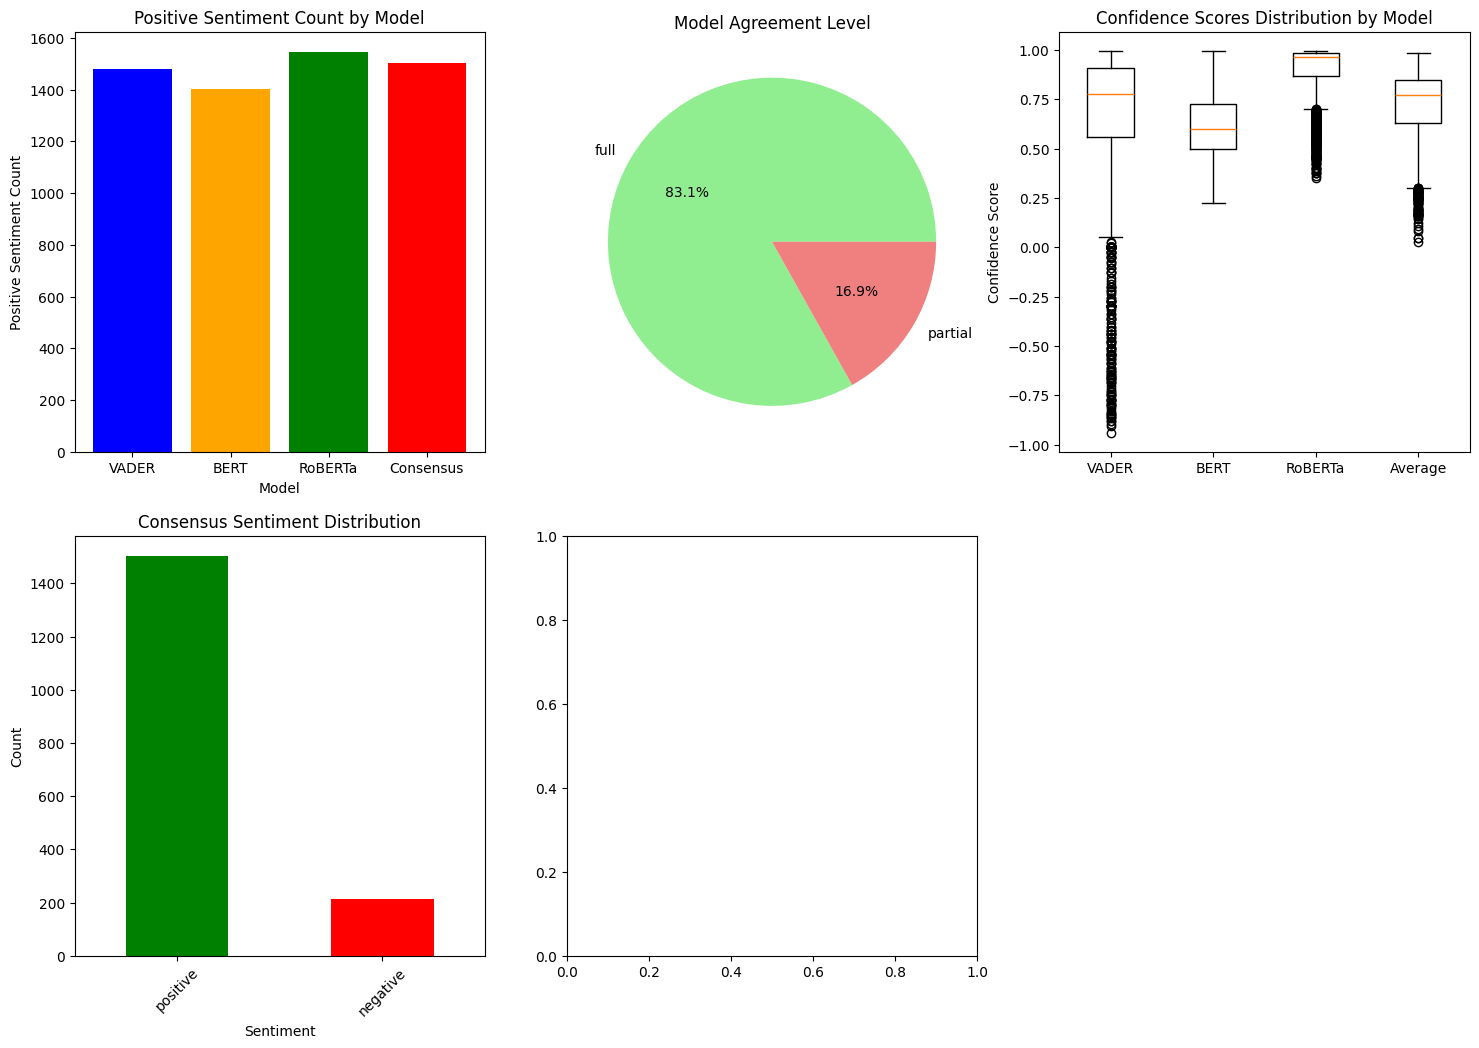

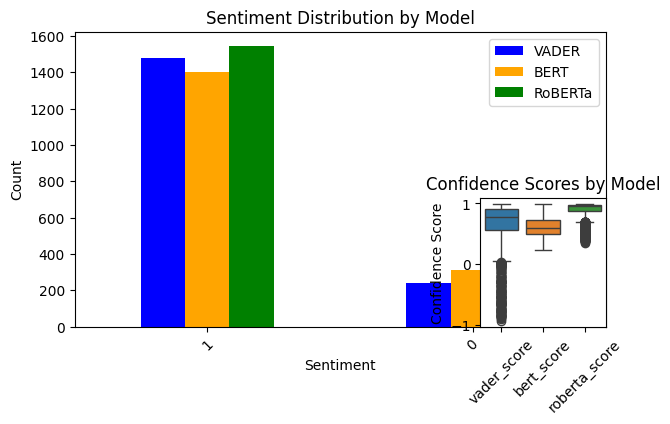


Top 10 Hotels by Number of Reviews (Consensus):
                                     total_reviews  positive_ratio_consensus  \
Hotel name                                                                     
Rydges World Square                            318                     0.824   
PARKROYAL Darling Harbour                      316                     0.877   
The Darling                                    183                     0.896   
Meriton Suites Zetland                         132                     0.879   
The Langham, Sydney                            126                     0.937   
Paradox Sydney                                 104                     0.904   
Pullman Grand Quay                             104                     0.865   
Amora Hotel Jamison Sydney                      99                     0.859   
The Sebel Quay West Suites                      98                     0.959   
Crowne Plaza Sydney Darling Harbour             82                     

In [2]:
# -*- coding: utf-8 -*-
"""Combine All Sentiment Analysis Results (3 Files Only).ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1_your_drive_link_here
"""

# Install required packages if needed
!pip install pandas openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define file paths
vader_file = '/content/drive/MyDrive/Colab Notebooks/hotel_reviews_with_sentiment.xlsx'
bert_file = '/content/drive/MyDrive/Colab Notebooks/hotel_reviews_bert_sentiment.xlsx'
roberta_file = '/content/drive/MyDrive/Colab Notebooks/hotel_reviews_roberta_lenient_sentiment.xlsx'
combined_output = '/content/drive/MyDrive/Colab Notebooks/hotel_reviews_combined_sentiment_final.xlsx'

# Load all files
print("Loading sentiment analysis files...")

try:
    # Load VADER results
    vader_df = pd.read_excel(vader_file)
    print(f"VADER file loaded: {vader_df.shape}")
    print(f"VADER columns: {vader_df.columns.tolist()}")

    # Load BERT results
    bert_df = pd.read_excel(bert_file)
    print(f"BERT file loaded: {bert_df.shape}")
    print(f"BERT columns: {bert_df.columns.tolist()}")

    # Load RoBERTa results
    roberta_df = pd.read_excel(roberta_file)
    print(f"RoBERTa file loaded: {roberta_df.shape}")
    print(f"RoBERTa columns: {roberta_df.columns.tolist()}")

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please make sure all sentiment analysis files exist in your Colab Notebooks folder")
    raise

# Standardize column names for merging
print("\nStandardizing column names...")

# Rename columns to avoid conflicts and maintain consistency
vader_df = vader_df.rename(columns={
    'sentiment_score': 'vader_score',
    'sentiment': 'vader_sentiment'
})

bert_df = bert_df.rename(columns={
    'sentiment_score': 'bert_score',
    'sentiment': 'bert_sentiment',
    'stars': 'bert_stars'
})

roberta_df = roberta_df.rename(columns={
    'sentiment_score': 'roberta_score',
    'sentiment_label': 'roberta_label',
    'sentiment_class': 'roberta_class',
    'sentiment_binary': 'roberta_sentiment'
})

# Keep only essential columns from each dataset
vader_cols = ['Hotel name', 'Review Summary', 'vader_score', 'vader_sentiment']
bert_cols = ['Hotel name', 'Review Summary', 'bert_score', 'bert_sentiment', 'bert_stars']
roberta_cols = ['Hotel name', 'Review Summary', 'roberta_score', 'roberta_sentiment']

vader_subset = vader_df[vader_cols].copy()
bert_subset = bert_df[bert_cols].copy()
roberta_subset = roberta_df[roberta_cols].copy()

# Merge all datasets
print("Merging all sentiment analysis results...")

# First merge VADER and BERT
merged_df = pd.merge(vader_subset, bert_subset,
                    on=['Hotel name', 'Review Summary'],
                    how='inner')  # Use inner join to ensure all models have data

# Then merge with RoBERTa
final_combined = pd.merge(merged_df, roberta_subset,
                         on=['Hotel name', 'Review Summary'],
                         how='inner')

print(f"Combined dataset shape: {final_combined.shape}")

# Check for missing data
print("\nMissing values in combined dataset:")
print(final_combined.isnull().sum())

# Create consensus sentiment column
print("\nCreating consensus sentiment analysis...")

def get_consensus_sentiment(row):
    """
    Create consensus sentiment based on all three models
    Using LENIENT approach: (Positive + Neutral) = 1, Negative = 0
    """
    sentiments = []

    # VADER sentiment (already binary: 1=positive, 0=negative)
    if pd.notna(row.get('vader_sentiment')):
        sentiments.append('positive' if row['vader_sentiment'] == 1 else 'negative')

    # BERT sentiment (binary: 1=positive, 0=negative)
    if pd.notna(row.get('bert_sentiment')):
        sentiments.append('positive' if row['bert_sentiment'] == 1 else 'negative')

    # RoBERTa sentiment (binary: 1=positive+neutral, 0=negative)
    if pd.notna(row.get('roberta_sentiment')):
        sentiments.append('positive' if row['roberta_sentiment'] == 1 else 'negative')

    if not sentiments:
        return 'unknown'

    # Count votes
    positive_count = sentiments.count('positive')
    negative_count = sentiments.count('negative')

    if positive_count > negative_count:
        return 'positive'
    elif negative_count > positive_count:
        return 'negative'
    else:
        return 'tie'

# Apply consensus function
final_combined['consensus_sentiment'] = final_combined.apply(get_consensus_sentiment, axis=1)
final_combined['consensus_binary'] = final_combined['consensus_sentiment'].apply(
    lambda x: 1 if x == 'positive' else (0 if x == 'negative' else np.nan)
)

# Calculate average confidence score
def get_average_confidence(row):
    scores = []
    if pd.notna(row.get('vader_score')):
        scores.append(row['vader_score'])
    if pd.notna(row.get('bert_score')):
        scores.append(row['bert_score'])
    if pd.notna(row.get('roberta_score')):
        scores.append(row['roberta_score'])

    return np.mean(scores) if scores else np.nan

final_combined['avg_confidence'] = final_combined.apply(get_average_confidence, axis=1)

# Add agreement column
def get_agreement_level(row):
    sentiments = []
    if pd.notna(row.get('vader_sentiment')):
        sentiments.append(row['vader_sentiment'])
    if pd.notna(row.get('bert_sentiment')):
        sentiments.append(row['bert_sentiment'])
    if pd.notna(row.get('roberta_sentiment')):
        sentiments.append(row['roberta_sentiment'])

    if len(sentiments) < 2:
        return 'partial'

    # Check if all available sentiments agree
    unique_sentiments = set(sentiments)
    return 'full' if len(unique_sentiments) == 1 else 'partial'

final_combined['agreement'] = final_combined.apply(get_agreement_level, axis=1)

# Analysis of results
print("\n" + "=" * 60)
print("COMBINED SENTIMENT ANALYSIS RESULTS")
print("=" * 60)

# Sentiment distribution across models
print("\nSentiment Distribution by Model:")
print("VADER:")
print(final_combined['vader_sentiment'].value_counts())
print("\nBERT:")
print(final_combined['bert_sentiment'].value_counts())
print("\nRoBERTa:")
print(final_combined['roberta_sentiment'].value_counts())
print("\nConsensus:")
print(final_combined['consensus_sentiment'].value_counts())

# Agreement analysis
agreement_stats = final_combined['agreement'].value_counts()
print(f"\nModel Agreement: {agreement_stats.get('full', 0)} full agreement, {agreement_stats.get('partial', 0)} partial agreement")

# Visualizations
plt.figure(figsize=(18, 12))

# Sentiment comparison across models
plt.subplot(2, 3, 1)
models = ['VADER', 'BERT', 'RoBERTa', 'Consensus']
positive_counts = [
    (final_combined['vader_sentiment'] == 1).sum(),
    (final_combined['bert_sentiment'] == 1).sum(),
    (final_combined['roberta_sentiment'] == 1).sum(),
    (final_combined['consensus_binary'] == 1).sum()
]

x_pos = np.arange(len(models))
plt.bar(x_pos, positive_counts, color=['blue', 'orange', 'green', 'red'])
plt.xlabel('Model')
plt.ylabel('Positive Sentiment Count')
plt.title('Positive Sentiment Count by Model')
plt.xticks(x_pos, models)

# Agreement chart
plt.subplot(2, 3, 2)
agreement_stats.plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
plt.title('Model Agreement Level')
plt.ylabel('')

# Confidence scores distribution
plt.subplot(2, 3, 3)
confidence_cols = ['vader_score', 'bert_score', 'roberta_score', 'avg_confidence']
confidence_data = final_combined[confidence_cols].dropna()

plt.boxplot([confidence_data['vader_score'],
             confidence_data['bert_score'],
             confidence_data['roberta_score'],
             confidence_data['avg_confidence']],
            labels=['VADER', 'BERT', 'RoBERTa', 'Average'])
plt.title('Confidence Scores Distribution by Model')
plt.ylabel('Confidence Score')

# Consensus sentiment
plt.subplot(2, 3, 4)
final_combined['consensus_sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Consensus Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Model comparison by sentiment
plt.subplot(2, 3, 5)
model_comparison = pd.DataFrame({
    'VADER': final_combined['vader_sentiment'].value_counts(),
    'BERT': final_combined['bert_sentiment'].value_counts(),
    'RoBERTa': final_combined['roberta_sentiment'].value_counts()
})
model_comparison.plot(kind='bar', color=['blue', 'orange', 'green'])
plt.title('Sentiment Distribution by Model')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Confidence by model
plt.subplot(2, 3, 6)
confidence_by_model = final_combined[['vader_score', 'bert_score', 'roberta_score']]
sns.boxplot(data=confidence_by_model)
plt.title('Confidence Scores by Model')
plt.ylabel('Confidence Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Hotel-wise analysis with consensus
hotel_consensus = final_combined.groupby('Hotel name').agg({
    'consensus_binary': ['count', 'mean'],
    'avg_confidence': 'mean',
    'vader_sentiment': 'mean',
    'bert_sentiment': 'mean',
    'roberta_sentiment': 'mean'
}).round(3)

hotel_consensus.columns = ['total_reviews', 'positive_ratio_consensus', 'avg_confidence',
                          'vader_positive_ratio', 'bert_positive_ratio', 'roberta_positive_ratio']
hotel_consensus = hotel_consensus.sort_values('total_reviews', ascending=False)

print("\nTop 10 Hotels by Number of Reviews (Consensus):")
print(hotel_consensus.head(10))

# Compare model performance for top hotels
top_hotels = hotel_consensus.head(5).index.tolist()
print(f"\nSentiment Comparison for Top {len(top_hotels)} Hotels:")

for hotel in top_hotels:
    hotel_data = final_combined[final_combined['Hotel name'] == hotel]
    print(f"\n{hotel}:")
    print(f"  VADER Positive: {(hotel_data['vader_sentiment'] == 1).mean():.1%}")
    print(f"  BERT Positive: {(hotel_data['bert_sentiment'] == 1).mean():.1%}")
    print(f"  RoBERTa Positive: {(hotel_data['roberta_sentiment'] == 1).mean():.1%}")
    print(f"  Consensus Positive: {(hotel_data['consensus_binary'] == 1).mean():.1%}")

# Model correlation analysis
print("\nCorrelation between Model Predictions:")
model_correlation = final_combined[['vader_sentiment', 'bert_sentiment', 'roberta_sentiment']].corr()
print(model_correlation)

# Save the combined results
final_combined.to_excel(combined_output, index=False)
print(f"\nCombined results saved to: {combined_output}")

# Show sample of combined data
print("\n" + "=" * 60)
print("SAMPLE OF COMBINED DATA")
print("=" * 60)
sample_cols = ['Hotel name', 'Review Summary',
               'vader_sentiment', 'bert_sentiment', 'roberta_sentiment',
               'consensus_sentiment', 'avg_confidence', 'agreement']
sample_data = final_combined[sample_cols].sample(8)
print(sample_data)

# Final statistics
print("\n" + "=" * 60)
print("FINAL STATISTICS")
print("=" * 60)
print(f"Total reviews in combined dataset: {len(final_combined)}")
print(f"Hotels covered: {final_combined['Hotel name'].nunique()}")

consensus_stats = final_combined['consensus_sentiment'].value_counts()
print(f"\nConsensus Sentiment:")
for sentiment, count in consensus_stats.items():
    print(f"  {sentiment}: {count} ({count/len(final_combined)*100:.1f}%)")

print(f"\nAverage confidence score: {final_combined['avg_confidence'].mean():.3f}")

# Model performance summary
print(f"\nModel Performance Summary:")
print(f"VADER Positive: {(final_combined['vader_sentiment'] == 1).mean():.1%}")
print(f"BERT Positive: {(final_combined['bert_sentiment'] == 1).mean():.1%}")
print(f"RoBERTa Positive: {(final_combined['roberta_sentiment'] == 1).mean():.1%}")
print(f"Consensus Positive: {(final_combined['consensus_binary'] == 1).mean():.1%}")

print("\nCombined analysis complete! ✅")
print(f"File saved: {combined_output}")

In [5]:
# -*- coding: utf-8 -*-
"""Add BERT and RoBERTa to VADER File.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1_your_drive_link_here
"""

# Install required packages if needed
!pip install pandas openpyxl
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define file paths
vader_file = '/content/drive/MyDrive/Colab Notebooks/hotel_reviews_with_sentiment.xlsx'
bert_file = '/content/drive/MyDrive/Colab Notebooks/hotel_reviews_bert_sentiment.xlsx'
roberta_file = '/content/drive/MyDrive/Colab Notebooks/hotel_reviews_roberta_lenient_sentiment.xlsx'
output_file = '/content/drive/MyDrive/Colab Notebooks/hotel_reviews_vader_plus_scores.xlsx' # Changed output file name

# Load all files
print("Loading sentiment analysis files...")

try:
    # Load VADER results (this will be our base file)
    vader_df = pd.read_excel(vader_file)
    print(f"VADER file loaded: {vader_df.shape}")
    print(f"VADER columns: {vader_df.columns.tolist()}")

    # Load BERT results
    bert_df = pd.read_excel(bert_file)
    print(f"BERT file loaded: {bert_df.shape}")
    print(f"BERT columns: {bert_df.columns.tolist()}")

    # Load RoBERTa results
    roberta_df = pd.read_excel(roberta_file)
    print(f"RoBERTa file loaded: {roberta_df.shape}")
    print(f"RoBERTa columns: {roberta_df.columns.tolist()}")

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please make sure all sentiment analysis files exist in your Colab Notebooks folder")
    raise

# Create the base dataframe by selecting all columns from the VADER dataframe
print("\nCreating base dataframe from VADER file...")
# Select all columns from VADER dataframe
combined_df = vader_df[[
    'Hotel name',
    'Reviewer Name',
    'Rating',
    'Traveller Type',
    'Date of Review',
    'Liked',
    'Disliked',
    'Review Summary',
    'Stay Duration',
    'Stay Date',
    'sentiment_score',
    'sentiment'
]].copy()

print(f"Base dataframe shape: {combined_df.shape}")
print(f"Base dataframe columns: {combined_df.columns.tolist()}")


# Rename columns in BERT and RoBERTa to avoid conflicts before merging scores
bert_df = bert_df.rename(columns={
    'sentiment_score': 'bert_score',
    'sentiment': 'bert_sentiment', # Keep the sentiment column
    'stars': 'bert_stars'
})

roberta_df = roberta_df.rename(columns={
    'sentiment_score': 'roberta_score',
    'sentiment_label': 'roberta_label',
    'sentiment_class': 'roberta_class',
    'sentiment_binary': 'roberta_sentiment' # Keep the binary sentiment column
})

# Select the score and sentiment columns and the merge keys from BERT and RoBERTa
bert_cols_to_add = ['Hotel name', 'Review Summary', 'bert_score', 'bert_sentiment'] # Include bert_sentiment
roberta_cols_to_add = ['Hotel name', 'Review Summary', 'roberta_score', 'roberta_sentiment'] # Include roberta_sentiment

bert_subset = bert_df[bert_cols_to_add].copy()
roberta_subset = roberta_df[roberta_cols_to_add].copy()

# Merge BERT scores and sentiment with the base dataframe
print("Adding BERT scores and sentiment to the base dataframe...")
combined_df = pd.merge(combined_df, bert_subset,
                      on=['Hotel name', 'Review Summary'],
                      how='left') # left join to keep all VADER rows

print(f"After adding BERT scores and sentiment: {combined_df.shape}")
print(f"BERT scores merged: {combined_df['bert_score'].notna().sum()} rows")
print(f"BERT sentiment merged: {combined_df['bert_sentiment'].notna().sum()} rows")


# Merge RoBERTa scores and sentiment
print("Adding RoBERTa scores and sentiment to the base dataframe...")
combined_df = pd.merge(combined_df, roberta_subset,
                      on=['Hotel name', 'Review Summary'],
                      how='left') # left join to keep all VADER rows

print(f"After adding RoBERTa scores and sentiment: {combined_df.shape}")
print(f"RoBERTa scores merged: {combined_df['roberta_score'].notna().sum()} rows")
print(f"RoBERTa sentiment merged: {combined_df['roberta_sentiment'].notna().sum()} rows")


# Check for missing data in the new score and sentiment columns
print("\nMissing values in score and sentiment columns:")
print(combined_df[['sentiment_score', 'sentiment', 'bert_score', 'bert_sentiment', 'roberta_score', 'roberta_sentiment']].isnull().sum())


# Save the final combined file
combined_df.to_excel(output_file, index=False)
print(f"\nFinal combined file saved to: {output_file}")
print(f"Final shape: {combined_df.shape}")

# Show sample of the final data
print("\n" + "=" * 60)
print("SAMPLE OF FINAL DATA")
print("=" * 60)

# Display the first 10 rows with the relevant columns
sample_columns = [
    'Hotel name',
    'Reviewer Name',
    'Rating',
    'Traveller Type',
    'Date of Review',
    'Liked',
    'Disliked',
    'Review Summary',
    'Stay Duration',
    'Stay Date',
    'sentiment_score', # VADER score
    'sentiment', # VADER sentiment
    'bert_score', # BERT score
    'bert_sentiment', # BERT sentiment
    'roberta_score', # RoBERTa score
    'roberta_sentiment' # RoBERTa sentiment
]

sample_data = combined_df[sample_columns].head(10)
display(sample_data)

print("\nOperation completed successfully! ✅")
print(f"VADER data with BERT and RoBERTa scores and sentiment added.")
print(f"Output file: {output_file}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading sentiment analysis files...
VADER file loaded: (1717, 14)
VADER columns: ['Hotel name', 'Reviewer Name', 'Rating', 'Traveller Type', 'Date of Review', 'Liked', 'Disliked', 'Review Summary', 'Stay Duration', 'Stay Date', 'Unnamed: 10', 'review_length', 'sentiment_score', 'sentiment']
BERT file loaded: (1717, 14)
BERT columns: ['Hotel name', 'Reviewer Name', 'Rating', 'Traveller Type', 'Date of Review', 'Liked', 'Disliked', 'Review Summary', 'Stay Duration', 'Stay Date', 'Unnamed: 10', 'stars', 'sentiment_score', 'sentiment']
RoBERTa file loaded: (1717, 16)
RoBERTa columns: ['Hotel name', 'Reviewer Name', 'Rating', 'Traveller Type', 'Date of Review', 'Liked', 'Disliked', 'Review Summary', 'Stay Duration', 'Stay Date', 'Unnamed: 10', 'review_length', 'sentiment_label', 'sentiment_score', 'sentiment_class', 'sentiment_binary']

Creating base dataframe fro

,Hotel name,Reviewer Name,Rating,Traveller Type,Date of Review,Liked,Disliked,Review Summary,Stay Duration,Stay Date,sentiment_score,sentiment,bert_score,bert_sentiment,roberta_score,roberta_sentiment
0,Veriu Camperdown,Verified traveller,8/10 Good,Travelled with family,2025-08-16 00:00:00,"cleanliness, communication, room comfort",NaN,great stay but could use more towels room was ...,2 nights,2025-08-01 00:00:00,0.4512,1,0.647402,1.0,0.797457,1
1,Veriu Camperdown,Verified traveller,10/10 Excellent,Business traveller,2025-07-04 00:00:00,"cleanliness, communication, room comfort",NaN,accommodation was fantastic the rooms were qui...,5 nights,2025-06-01 00:00:00,0.5574,1,0.585517,1.0,0.980643,1
2,Veriu Camperdown,Shinkichi,10/10 Excellent,NaN,2025-08-20 00:00:00,"cleanliness, amenities, communication, propert...",NaN,the cleaning day didn t fit our itinerary we h...,4 nights,2025-08-01 00:00:00,0.0240,0,0.482898,0.0,0.901593,0
3,Veriu Camperdown,Nick,10/10 Excellent,Travelled with group,2025-04-17 00:00:00,"cleanliness, amenities, communication, propert...",NaN,great place and very accommodating,1 night,2025-04-01 00:00:00,0.6249,1,0.801425,1.0,0.978070,1
4,Veriu Camperdown,Carlos,10/10 Excellent,"Business traveller, with family",2025-04-30 00:00:00,"cleanliness, amenities, communication, propert...",NaN,good locality,1 night,2025-04-01 00:00:00,0.4404,1,0.538897,1.0,0.646385,1
5,Veriu Camperdown,Brad,10/10 Excellent,Travelled with group,2025-02-10 00:00:00,"cleanliness, amenities, communication, propert...",NaN,this was a great place,2 nights,2025-02-01 00:00:00,0.6249,1,0.702339,1.0,0.961236,1
6,Veriu Camperdown,Teresa,8/10 Good,Travelled with group,2025-05-10 00:00:00,"cleanliness, amenities, communication, propert...",NaN,just missing an aircon in the bedroom,2 nights,2025-04-01 00:00:00,-0.2960,0,0.308762,0.0,0.545644,0
7,Veriu Camperdown,henry,10/10 Excellent,With partner & family,2025-01-19 00:00:00,"cleanliness, communication, room comfort",NaN,great location and good value nice size apartment,1 night,2025-01-01 00:00:00,0.9042,1,0.628435,1.0,0.979791,1
8,Veriu Camperdown,Morgan,8/10 Good,Travelled with family,2024-08-11 00:00:00,"cleanliness, amenities, communication, propert...",NaN,quite adequate for a one night stay close to t...,1 night,2024-08-01 00:00:00,0.2944,1,0.567965,1.0,0.517904,1
9,Veriu Camperdown,Renne,10/10 Excellent,"Business traveller, with family",1 Sept 2024,"cleanliness, amenities, communication, propert...",NaN,excellent customer service clean safe hotel wi...,10 nights,2024-08-01 00:00:00,0.9186,1,0.781716,1.0,0.974500,1



Operation completed successfully! ✅
VADER data with BERT and RoBERTa scores and sentiment added.
Output file: /content/drive/MyDrive/Colab Notebooks/hotel_reviews_vader_plus_scores.xlsx
